In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import RobustScaler
import plotly.graph_objs as go
from plotly.offline import iplot
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    handle="mlg-ulb/creditcardfraud",
    path="creditcard.csv"
)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **EDA:**

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isna().sum().max() # No null values

0

In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
# Calculate the percentage of each class
class_counts = df['Class'].value_counts(normalize=True) * 100

print("Percentage of Non-Fraud (0):", class_counts[0])
print("Percentage of Fraud (1):", class_counts[1])

Percentage of Non-Fraud (0): 99.82725143693798
Percentage of Fraud (1): 0.1727485630620034


# **Visualization :**

/tmp/ipykernel_3334/3109524482.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Class', ylabel='count'>

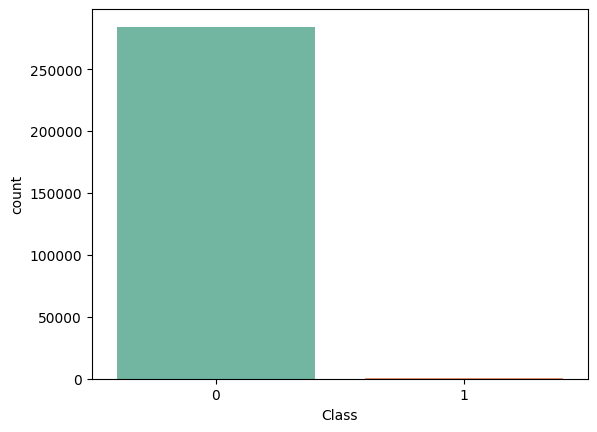

In [ ]:
sns.countplot(
    x = "Class",
    data = df,
    palette = "Set2"
)

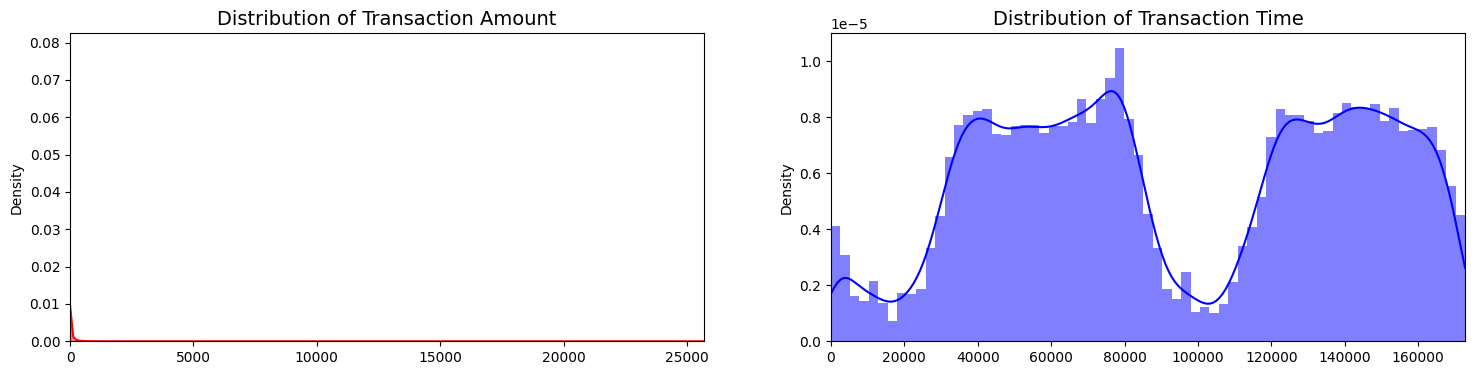

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.histplot(amount_val, ax=ax[0], color='r', kde=True, stat="density", linewidth=0)
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.histplot(time_val, ax=ax[1], color='b', kde=True, stat="density", linewidth=0)
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

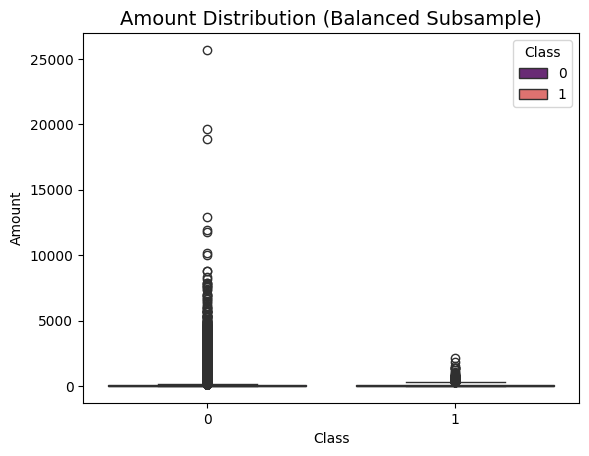

In [ ]:
sns.boxplot(x="Class", y="Amount", hue="Class", data=df, palette="magma")
plt.title('Amount Distribution (Balanced Subsample)', fontsize=14)
plt.show()

In [ ]:
fraud = df.loc[df['Class'] == 1]

trace = go.Scatter(
    x = fraud['Time'],y = fraud['Amount'],
    name="Amount",
     marker=dict(
                color='rgb(238,23,11)',
                line=dict(
                    color='red',
                    width=1),
                opacity=0.5,
            ),
    text= fraud['Amount'],
    mode = "markers"
)
data = [trace]
layout = dict(title = 'Amount of fraudulent transactions',
          xaxis = dict(title = 'Time [s]', showticklabels=True),
          yaxis = dict(title = 'Amount'),
          hovermode='closest'
         )
fig = dict(data=data, layout=layout)
iplot(fig, filename='fraud-amount')

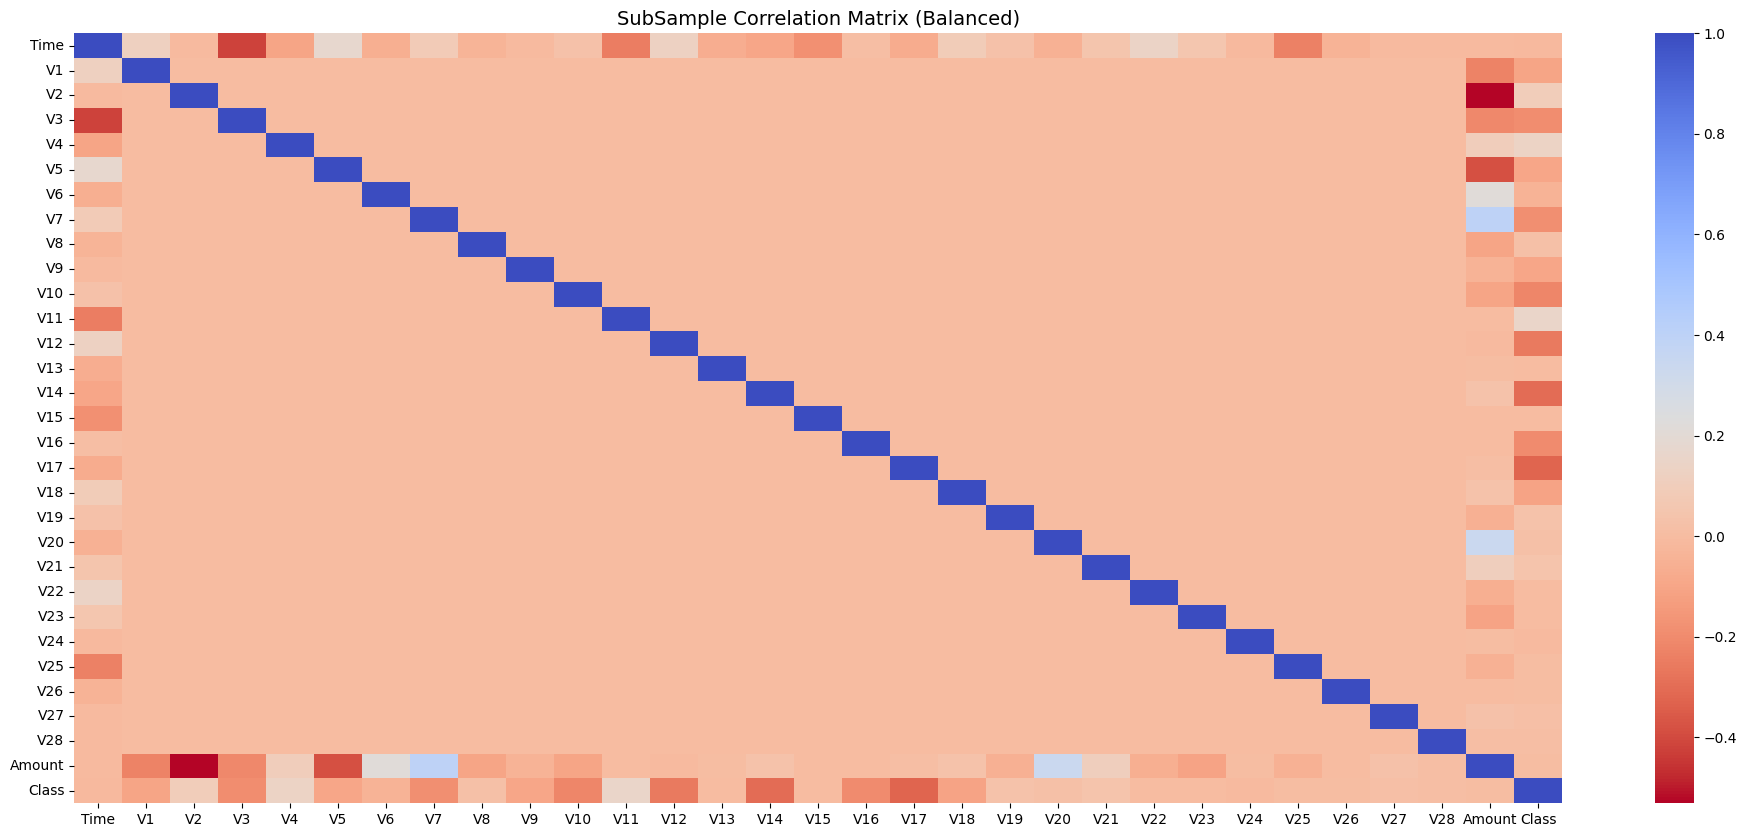

In [ ]:
f, ax = plt.subplots(figsize=(24,10))

# Using the balanced subsample to see clear correlations
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title("SubSample Correlation Matrix (Balanced)", fontsize=14)
plt.show()

# **Scaling:**

In [ ]:
rs = RobustScaler()
df["Time"] = rs.fit_transform(df[["Time"]])
df["Amount"] = rs.fit_transform(df[["Amount"]])
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0


In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]

# Count the number of fraud vs non-fraud cases in the duplicate set
dup_class_counts = duplicate_rows['Class'].value_counts()

print("Frequency of classes in duplicated rows:")
print(dup_class_counts)

# Calculate the percentage
if 1 in dup_class_counts:
    print(f"\nOut of {len(duplicate_rows)} duplicate entries, {dup_class_counts[1]} are Fraudulent (Class 1).")
else:
    print("\nNone of the duplicate rows are Fraudulent.")

Frequency of classes in duplicated rows:
Class
0    1822
1      32
Name: count, dtype: int64

Out of 1854 duplicate entries, 32 are Fraudulent (Class 1).


In [ ]:
duplicate_mask = df.duplicated(keep='first')

# We only want to drop a row if it is a duplicate AND it is NOT fraud (Class 0)
drop_condition = (duplicate_mask) & (df['Class'] == 0)
df = df[~drop_condition].reset_index(drop=True)

# Data spliting:
x = df.drop('Class', axis=1)
y = df['Class']

x.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274
1,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825
2,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721


In [ ]:
y.head(2)

,Class
0,0
1,0


In [ ]:
y.value_counts()

,count
Class,
0,283253
1,492


In [ ]:
df.shape

(283745, 31)

In [ ]:
model = Sequential([
    Input(shape=(x.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [ ]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
from IPython.terminal.interactiveshell import validate
history = model.fit(
    x, y,
    validation_split = 0.2,
    epochs = 10,
    callbacks = [early_stopping],
    verbose = 1
)

Epoch 1/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9895 - loss: 0.0314 - val_accuracy: 0.9995 - val_loss: 0.0035
Epoch 2/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9991 - loss: 0.0046 - val_accuracy: 0.9995 - val_loss: 0.0028
Epoch 3/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9992 - loss: 0.0042 - val_accuracy: 0.9995 - val_loss: 0.0028
Epoch 4/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 5/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9995 - val_loss: 0.0037
Epoch 6/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 7/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 8/10
7094/7094 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9993 - loss: 0

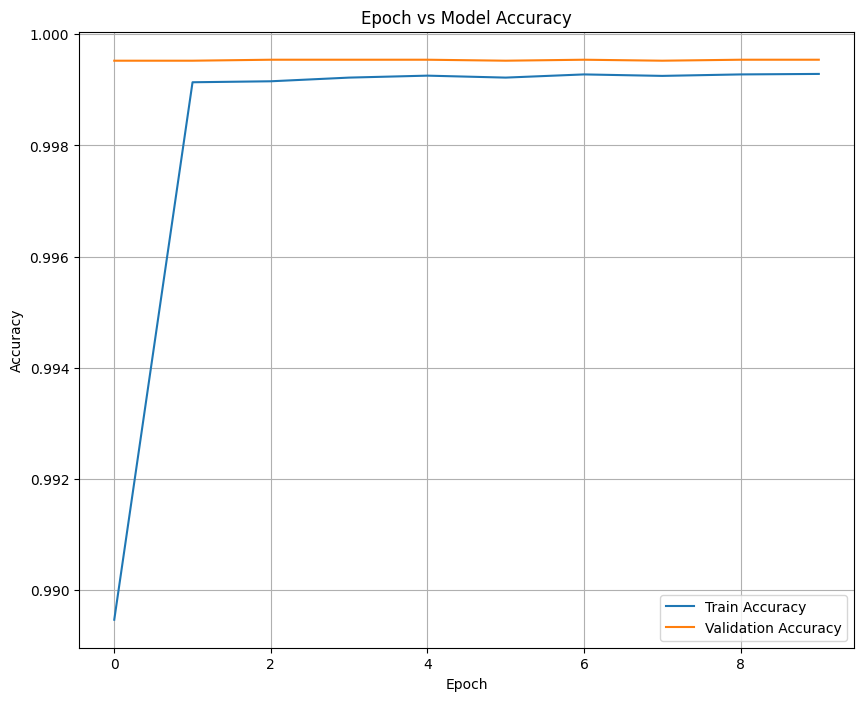

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Epoch vs Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

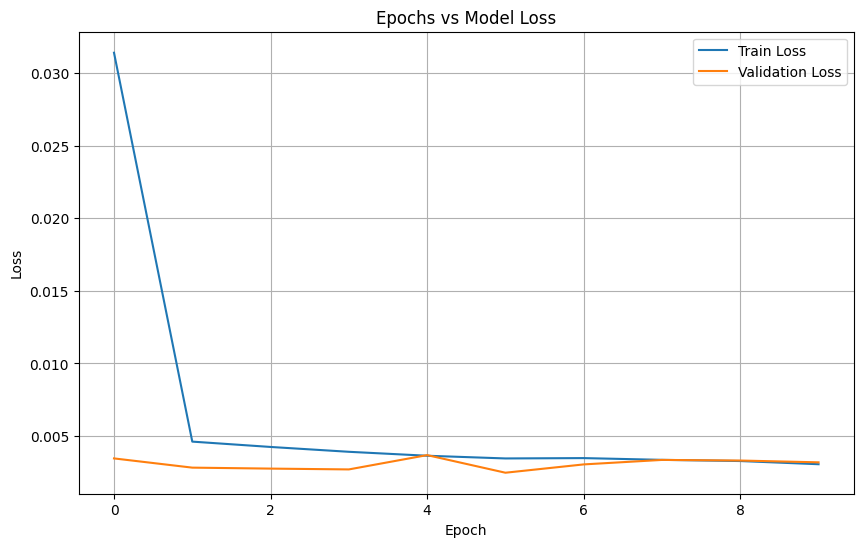

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Epochs vs Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

8868/8868 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step


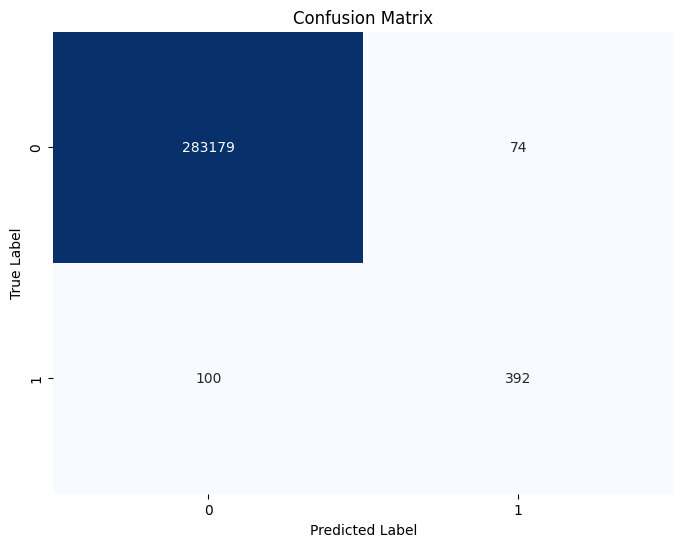


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    283253
           1       0.84      0.80      0.82       492

    accuracy                           1.00    283745
   macro avg       0.92      0.90      0.91    283745
weighted avg       1.00      1.00      1.00    283745



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, auc
import numpy as np

# Get predictions
y_pred_prob = model.predict(x)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y, y_pred))

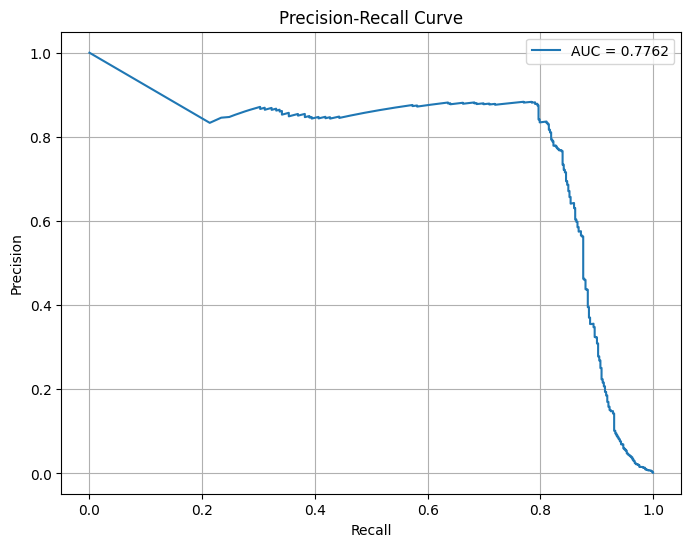

In [ ]:
# Calculate Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y, y_pred_prob)
pr_auc = auc(recall, precision)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AUC = {pr_auc:.4f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.grid(True)
plt.show()